# Comparación de modelos generativos — métricas físicas (Colab / G4 90GB)

Compara **DDPM**, **CVAE-Xception** y **CVAE-ViT** sobre **todo el split de test** usando 4 métricas físicas:
**Magnetization**, **Abs. Magnetization**, **Spin Correlation**, **Peak Wavevector**.

**Protocolo**: por cada θ del test se generan `K=32` imágenes desde el prior/condicional, se calcula cada observable por muestra y se promedia sobre las K. Se reporta **R²(gen vs real)** por métrica (general y por las 6 fases magnéticas).

**Ejecución por etapas** (evita el choque TF/PyTorch): cada modelo genera, calcula sus métricas y **cachea a disco**; luego se liberan sus recursos antes del siguiente. Al final se cargan los 3 cachés y se hacen las 5 gráficas.

**5 gráficas**:
1. General — R² de cada métrica × modelo (12 barras).
2–5. Por métrica — R² por fase × modelo (18 barras cada una).

**Inputs (Kaggle datasets, se descargan en Colab)**:
- `carloscanamejoy/dataset-spines-united-v2` → `dataset_unificado_v2.npz`
- `carloscanamejoy/weights-models` → `ddpm_spines_final_39crop.pt`
- `carloscanamejoy/weights-cvae-models` → `cvae_xception.h5`, `cvae_vit.h5`
- `carloscanamejoy/weights-xception-model` → `modelo_xception_fulldatabaseV3100.h5`
- `carloscanamejoy/physicalmetrics` → `metrics.py`

In [1]:
# ============================================================
# CONFIGURACIÓN — edita aquí
# ============================================================
K = 32            # nº de imágenes generadas por θ (se promedia)
SEED = 42         # semilla del split (coincide con el entrenamiento)
GEN_SEED = 123    # semilla del ruido de generación
FAST_STEPS = 50  # pasos DDIM del DDPM (bajar a 50 ~duplica velocidad del DDPM)

# Las K muestras de cada θ se generan EN EL MISMO BATCH para saturar la GPU.
# Batch efectivo de sampling = THETA_CHUNK * K. Con 95 GB sube THETA_CHUNK si la GPU va holgada.
THETA_CHUNK = 128  # 64 θ × 32 = 2048 imágenes por llamada de sampling

# Prueba rápida con un subconjunto (None = todo el test ~25.4k θ)
LIMIT_THETA = None

# Modelos a ejecutar (cada etapa cachea a disco; puedes correr en sesiones distintas)
RUN_DDPM     = True
RUN_XCEPTION = True
RUN_VIT      = True

import os
CACHE_DIR = "/content/eval_cache"
os.makedirs(CACHE_DIR, exist_ok=True)

MODELS = ["DDPM", "CVAE-Xception", "CVAE-ViT"]
METRICS = ["magnetization", "abs_magnetization", "spin_correlation", "peak_wavevector"]
METRIC_LABEL = {
    "magnetization":     "Magnetization",
    "abs_magnetization": "Abs. Magnetization",
    "spin_correlation":  "Spin Correlation",
    "peak_wavevector":   "Peak Wavevector",
}
print(f"K={K} | THETA_CHUNK={THETA_CHUNK} → batch efectivo {THETA_CHUNK*K} | métricas: {[METRIC_LABEL[m] for m in METRICS]}")




K=32 | THETA_CHUNK=128 → batch efectivo 4096 | métricas: ['Magnetization', 'Abs. Magnetization', 'Spin Correlation', 'Peak Wavevector']


In [2]:
# ============================================================
# Subir kaggle.json (Colab) y descargar datasets
# ============================================================
from google.colab import files
import json, pathlib

KAGGLE_DIR = pathlib.Path.home() / ".kaggle"
KAGGLE_DIR.mkdir(exist_ok=True)
KAGGLE_JSON = KAGGLE_DIR / "kaggle.json"

if not KAGGLE_JSON.exists():
    print("Sube tu kaggle.json (botón 'Choose Files')...")
    uploaded = files.upload()
    src = next((k for k in uploaded if k.endswith(".json")), None)
    if src is None:
        raise RuntimeError("No se subió ningún archivo .json")
    with open(KAGGLE_JSON, "wb") as f:
        f.write(uploaded[src])
os.chmod(KAGGLE_JSON, 0o600)
print(f"kaggle.json OK en {KAGGLE_JSON}")

os.makedirs("/content/data", exist_ok=True)
os.makedirs("/content/weights", exist_ok=True)
!kaggle datasets download -d carloscanamejoy/dataset-spines-united-v2 -p /content/data    --unzip
!kaggle datasets download -d carloscanamejoy/weights-models           -p /content/weights --unzip
!kaggle datasets download -d carloscanamejoy/weights-cvae-models      -p /content/weights --unzip
!kaggle datasets download -d carloscanamejoy/weights-xception-model   -p /content/weights --unzip
!kaggle datasets download -d carloscanamejoy/physicalmetrics          -p /content/weights --unzip
!kaggle datasets download -d carloscanamejoy/weights-vit-model          -p /content/weights --unzip
print("\nDescargas completas.")

Sube tu kaggle.json (botón 'Choose Files')...


Saving kaggle.json to kaggle.json
kaggle.json OK en /root/.kaggle/kaggle.json
Dataset URL: https://www.kaggle.com/datasets/carloscanamejoy/dataset-spines-united-v2
License(s): unknown
100% 421M/421M [00:21<00:00, 20.7MB/s]

Dataset URL: https://www.kaggle.com/datasets/carloscanamejoy/weights-models
License(s): apache-2.0
100% 807M/807M [00:39<00:00, 21.2MB/s]

403 Client Error: Forbidden for url: https://api.kaggle.com/v1/datasets.DatasetApiService/GetDatasetMetadata
Dataset URL: https://www.kaggle.com/datasets/carloscanamejoy/weights-xception-model
License(s): apache-2.0
100% 769M/769M [00:36<00:00, 22.2MB/s]

Dataset URL: https://www.kaggle.com/datasets/carloscanamejoy/physicalmetrics
License(s): unknown
100% 3.38k/3.38k [00:00<00:00, 12.2MB/s]

Dataset URL: https://www.kaggle.com/datasets/carloscanamejoy/weights-vit-model
License(s): unknown
100% 2.96G/2.96G [02:20<00:00, 22.7MB/s]


Descargas completas.


In [3]:
!kaggle datasets download -d carloscanamejoy/weights-vit-model   -p /content/weights --unzip

Dataset URL: https://www.kaggle.com/datasets/carloscanamejoy/weights-vit-model
License(s): unknown
  1% 22.0M/2.96G [00:02<04:58, 10.6MB/s]
User cancelled operation


In [2]:
# ============================================================
# Rutas (Colab) y carga de metrics.py
# ============================================================
import sys, time, math, importlib.util, gc
import numpy as np

DATASET_PATH  = "/content/data/dataset_unificado_v2.npz"
DDPM_CKPT     = "/content/weights/ddpm_spines_final_39crop.pt"
CVAE_XPN_CKPT = "/content/weights/cvae_xception.h5"
CVAE_VIT_CKPT = "/content/weights/cvae_vit.h5"
XPN_BACKBONE  = "/content/weights/modelo_xception_fulldatabaseV3100.h5"
METRICS_PATH  = "/content/weights/metrics.py"

for tag, p in [("dataset", DATASET_PATH), ("ddpm", DDPM_CKPT),
               ("cvae_xception", CVAE_XPN_CKPT), ("cvae_vit", CVAE_VIT_CKPT),
               ("xception backbone", XPN_BACKBONE), ("metrics", METRICS_PATH)]:
    print(("OK " if os.path.exists(p) else "FALTA"), tag, "->", p)

spec = importlib.util.spec_from_file_location("metrics", METRICS_PATH)
metrics = importlib.util.module_from_spec(spec); spec.loader.exec_module(metrics)
sys.modules["metrics"] = metrics
from metrics import (STRUCTURE_NAMES, STRUCTURE_COLORS, MODEL_COLORS, MASK,
                     get_structure_label, magnetization, abs_magnetization,
                     cnn_correlation, structure_factor, azimuthal_average,
                     apply_figure_style)
apply_figure_style()
print("\nmetrics.py cargado | fases:", STRUCTURE_NAMES)

OK  dataset -> /content/data/dataset_unificado_v2.npz
OK  ddpm -> /content/weights/ddpm_spines_final_39crop.pt
OK  cvae_xception -> /content/weights/cvae_xception.h5
OK  cvae_vit -> /content/weights/cvae_vit.h5
OK  xception backbone -> /content/weights/modelo_xception_fulldatabaseV3100.h5
OK  metrics -> /content/weights/metrics.py

metrics.py cargado | fases: ['Ferromagnetic', 'Helical', 'Labyrinthine & Conical', 'Bimeron', 'Skyrmions', 'Field-Saturated']


In [3]:
# ============================================================
# Dataset + split de test (SEED=42, 70/15/15) + scaler train-fit.
# Réplica del make_split del entrenamiento (subsample 100%, mismo seed).
# ============================================================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

data   = np.load(DATASET_PATH)
imgs   = data["img"].astype(np.float32)
params = data["params"].astype(np.float32)
labels = data["labels"].astype(int)
if imgs.ndim == 3:
    imgs = imgs[..., np.newaxis]
Nfull = len(imgs)

rng = np.random.RandomState(SEED)
sub_idx = rng.choice(Nfull, size=Nfull, replace=False)
idx_all = np.arange(len(sub_idx))
idx_tr, idx_tmp = train_test_split(idx_all, test_size=0.30, random_state=SEED)
idx_va, idx_te  = train_test_split(idx_tmp, test_size=0.50, random_state=SEED)
scaler = MinMaxScaler().fit(params[sub_idx][idx_tr])

test_global = sub_idx[idx_te]
eval_imgs   = imgs[test_global]                                   # (T, 39, 39, 1) originales
eval_params = params[test_global]
eval_phase  = np.array([get_structure_label(c) for c in labels[test_global]])
eval_cond   = scaler.transform(eval_params).astype(np.float32)    # θ normalizado

if LIMIT_THETA is not None:
    eval_imgs, eval_params = eval_imgs[:LIMIT_THETA], eval_params[:LIMIT_THETA]
    eval_phase, eval_cond = eval_phase[:LIMIT_THETA], eval_cond[:LIMIT_THETA]

n_theta = len(eval_cond)
print(f"test θ a evaluar: {n_theta:,}  (LIMIT_THETA={LIMIT_THETA})")
for ph in STRUCTURE_NAMES:
    print(f"  {ph:24s} {int((eval_phase==ph).sum()):6,}")

test θ a evaluar: 25,451  (LIMIT_THETA=None)
  Ferromagnetic             3,886
  Helical                  15,206
  Labyrinthine & Conical    2,918
  Bimeron                     921
  Skyrmions                 1,562
  Field-Saturated             958


In [4]:
# ============================================================
# Las 4 métricas físicas — versión CPU (referencia, = metrics.py)
# y versión GPU vectorizada (torch). peak_wavevector = q del máx radial de S(q).
# ============================================================
import torch
_GPU = "cuda" if torch.cuda.is_available() else "cpu"

# --- CPU (idéntica a metrics.py): se usa para los valores REALES y la verificación ---
def four_metrics(img39):
    q, sq = azimuthal_average(structure_factor(img39))
    qpeak = float(q[np.argmax(sq)]) if len(sq) else np.nan
    return (float(magnetization(img39)),
            float(abs_magnetization(img39)),
            float(cnn_correlation(img39)),
            qpeak)

# --- GPU: precomputar máscara y binning radial (réplica EXACTA de metrics.py) ---
_H = _W = 39
_MASK_T = torch.tensor(MASK, dtype=torch.bool, device=_GPU)         # (39,39)
_cy, _cx = _H // 2, _W // 2
_Y, _X = np.ogrid[:_H, :_W]
_R = np.sqrt((_X - _cx) ** 2 + (_Y - _cy) ** 2).astype(int)         # radios enteros (= metrics.py)
_max_r = min(_cy, _cx)
_R_T = torch.tensor(_R, dtype=torch.long, device=_GPU)
_RING_IDX = [(_R_T == r) for r in range(1, _max_r + 1)]            # anillos precomputados
_RING_R = torch.tensor([r for r in range(1, _max_r + 1)], dtype=torch.float32, device=_GPU)
# correlación NN: máscaras de pares válidos (0,1) y (1,0)
_NN = []
for _dy, _dx in [(0, 1), (1, 0)]:
    _valid = MASK[:-_dy or None, :-_dx or None] & MASK[_dy:, _dx:]
    _NN.append((_dy, _dx, torch.tensor(_valid, dtype=torch.bool, device=_GPU)))

def _as_gpu(imgs):
    """Acepta numpy, tensor torch o tensor TF; devuelve torch float32 (B,39,39) en GPU."""
    if isinstance(imgs, torch.Tensor):
        return imgs.to(_GPU, dtype=torch.float32)
    # TF EagerTensor → DLPack (cero copia GPU) o numpy de respaldo
    try:
        import tensorflow as tf
        if isinstance(imgs, tf.Tensor):
            from torch.utils.dlpack import from_dlpack
            return from_dlpack(tf.experimental.dlpack.to_dlpack(imgs)).to(_GPU, dtype=torch.float32)
    except Exception:
        pass
    return torch.as_tensor(np.asarray(imgs), dtype=torch.float32, device=_GPU)

def four_metrics_gpu(imgs):
    """imgs: (B,39,39) en [-1,1] (numpy/torch/TF). Devuelve (B,4) numpy:
       magnetization, abs_magnetization, spin_correlation, peak_wavevector."""
    x = _as_gpu(imgs)
    flat = x[:, _MASK_T]                                            # (B, n_in)
    mag = flat.mean(dim=1)
    mag_abs = mag.abs()

    total = torch.zeros(x.shape[0], device=_GPU); count = 0
    for dy, dx, vm in _NN:
        a = x[:, :x.shape[1]-dy if dy else None, :x.shape[2]-dx if dx else None]
        b = x[:, dy:, dx:]
        total = total + (a * b)[:, vm].sum(dim=1)
        count += int(vm.sum())
    corr = total / count

    N = _H * _W
    ft = torch.fft.fftshift(torch.fft.fft2(x), dim=(-2, -1))
    sq = (ft.abs() ** 2) / N                                        # (B,39,39)
    rm = torch.stack([sq[:, ring].mean(dim=1) for ring in _RING_IDX], dim=1)  # (B,n_rings)
    qpeak = _RING_R[rm.argmax(dim=1)]

    return torch.stack([mag, mag_abs, corr, qpeak], dim=1).cpu().numpy()

# Valor real (CPU, = metrics.py exacto): se calcula una sola vez.
REAL_CACHE = os.path.join(CACHE_DIR, "real_metrics.npz")
if os.path.exists(REAL_CACHE):
    real_vals = dict(np.load(REAL_CACHE))
    print("Métricas reales cargadas de caché.")
else:
    real_arr = np.array([four_metrics(eval_imgs[i, :, :, 0]) for i in range(n_theta)])
    real_vals = {m: real_arr[:, j] for j, m in enumerate(METRICS)}
    np.savez_compressed(REAL_CACHE, **real_vals)
    print(f"Métricas reales calculadas y cacheadas → {REAL_CACHE}")

Métricas reales cargadas de caché.


In [5]:
# ============================================================
# Helper común — las K muestras de cada θ se generan EN EL MISMO BATCH.
# Por cada chunk de THETA_CHUNK θ:
#   - se repite cada θ K veces  → batch de (chunk*K)
#   - UNA sola llamada de sampling genera las chunk*K imágenes (satura la GPU)
#   - métricas vectorizadas en GPU sobre todo el batch
#   - se reagrupa (chunk, K, 4) y se promedia sobre K
# Esto evita el bucle serial de K llamadas con batch pequeño (el cuello real).
# ============================================================
def run_model(model_name, generate_batch_fn):
    """generate_batch_fn(cond_np) -> tensor (B,39,39) en [-1,1] EN GPU (torch o TF)."""
    cache = os.path.join(CACHE_DIR, f"gen_metrics_{model_name}.npz")
    if os.path.exists(cache):
        print(f"[{model_name}] ya cacheado → {cache}. Salto generación.")
        return
    gen_vals = {m: np.full(n_theta, np.nan) for m in METRICS}
    t0 = time.time()
    for i0 in range(0, n_theta, THETA_CHUNK):
        i1 = min(i0 + THETA_CHUNK, n_theta)
        chunk = i1 - i0
        cond_rep = np.repeat(eval_cond[i0:i1], K, axis=0)     # (chunk*K, 8): θ0,θ0,...,θ1,θ1,...
        gen = generate_batch_fn(cond_rep)                     # (chunk*K, 39, 39) en GPU
        met = four_metrics_gpu(gen)                           # (chunk*K, 4) numpy
        met = met.reshape(chunk, K, 4)                        # agrupar por θ
        mean_over_k = np.nanmean(met, axis=1)                 # (chunk, 4)
        for jm, m in enumerate(METRICS):
            gen_vals[m][i0:i1] = mean_over_k[:, jm]
        if (i0 // THETA_CHUNK) % 5 == 0:
            done = i1; rate = done / (time.time() - t0 + 1e-9)
            eta = (n_theta - done) / rate / 60
            print(f"  [{model_name}] {done:>6}/{n_theta} θ | {rate:.1f} θ/s | ETA {eta:.1f} min")
    np.savez_compressed(cache, **gen_vals)
    print(f"[{model_name}] hecho en {(time.time()-t0)/60:.1f} min → {cache}")

def free():
    gc.collect()
    try:
        import torch; torch.cuda.empty_cache()
    except Exception:
        pass

# --- Verificación GPU vs CPU: las métricas GPU deben coincidir con metrics.py ---
def verify_gpu_metrics():
    import torch
    dev = "cuda" if torch.cuda.is_available() else "cpu"
    sample = eval_imgs[:50, :, :, 0].astype(np.float32)            # 50 imágenes reales
    cpu = np.array([four_metrics(sample[i]) for i in range(len(sample))])
    gpu = four_metrics_gpu(torch.tensor(sample, device=dev))
    diff = np.nanmax(np.abs(cpu - gpu), axis=0)
    print("max |GPU - CPU| por métrica:", dict(zip(METRICS, diff.round(6))))
    assert np.all(diff < 1e-3), "Las métricas GPU difieren de metrics.py — revisar."
    print("✅ Métricas GPU coinciden con metrics.py (CPU).")

verify_gpu_metrics()

max |GPU - CPU| por métrica: {'magnetization': np.float64(0.0), 'abs_magnetization': np.float64(0.0), 'spin_correlation': np.float64(0.0), 'peak_wavevector': np.float64(0.0)}
✅ Métricas GPU coinciden con metrics.py (CPU).


## Etapa A — DDPM (PyTorch)
Genera con el DDPM, cachea sus métricas y libera la GPU antes de pasar a TF.

In [6]:
if RUN_DDPM and not os.path.exists(os.path.join(CACHE_DIR, "gen_metrics_DDPM.npz")):
    import torch, torch.nn as nn, torch.nn.functional as F
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
    IMG_SIZE, CROP_TO, COND_DIM, T_STEPS = 40, 39, 8, 1000
    BETA_START, BETA_END = 1e-4, 0.02

    # ---- Arquitectura IDÉNTICA a ddpm_spines_train.ipynb (nombres exactos para load_state_dict) ----
    class DDPMScheduler:
        def __init__(self, T=1000, beta_start=1e-4, beta_end=0.02, schedule='cosine', device='cpu'):
            self.T = T
            if schedule == 'linear':
                betas = torch.linspace(beta_start, beta_end, T, device=device)
            elif schedule == 'cosine':
                steps = T + 1; s = 0.008
                x = torch.linspace(0, T, steps, device=device)
                ac = torch.cos(((x / T) + s) / (1 + s) * math.pi * 0.5) ** 2
                ac = ac / ac[0]
                betas = (1 - (ac[1:] / ac[:-1])).clamp(max=0.999)
            else:
                raise ValueError(schedule)
            alphas = 1.0 - betas
            ac = torch.cumprod(alphas, dim=0)
            self.sqrt_alphas_cumprod = ac.sqrt()
            self.sqrt_one_minus_alphas_cumprod = (1.0 - ac).sqrt()
            self.betas = betas; self.alphas = alphas; self.alphas_cumprod = ac

    def sinusoidal_embedding(t, dim):
        half = dim // 2
        freqs = torch.exp(-math.log(10000) * torch.arange(half, device=t.device).float() / (half - 1))
        args = t[:, None].float() * freqs[None]
        return torch.cat([args.sin(), args.cos()], dim=-1)

    class TimeCondEmbedding(nn.Module):
        def __init__(self, t_dim, cond_in, out_dim):
            super().__init__()
            self.t_mlp = nn.Sequential(nn.Linear(t_dim, out_dim), nn.SiLU(), nn.Linear(out_dim, out_dim))
            self.c_mlp = nn.Sequential(nn.Linear(cond_in, out_dim), nn.SiLU(), nn.Linear(out_dim, out_dim))
        def forward(self, t, cond):
            t_emb = sinusoidal_embedding(t, self.t_mlp[0].in_features)
            return self.t_mlp(t_emb) + self.c_mlp(cond)

    class ResBlock(nn.Module):
        def __init__(self, in_ch, out_ch, emb_dim, groups=8, dropout=0.0):
            super().__init__()
            self.norm1 = nn.GroupNorm(groups, in_ch); self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
            self.norm2 = nn.GroupNorm(groups, out_ch); self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
            self.emb_proj = nn.Linear(emb_dim, out_ch)
            self.dropout = nn.Dropout(dropout) if dropout > 0 else nn.Identity()
            self.skip = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()
        def forward(self, x, emb):
            h = F.silu(self.norm1(x)); h = self.conv1(h)
            h = h + self.emb_proj(F.silu(emb))[:, :, None, None]
            h = F.silu(self.norm2(h)); h = self.dropout(h); h = self.conv2(h)
            return h + self.skip(x)

    class SelfAttention(nn.Module):
        def __init__(self, ch, groups=8):
            super().__init__()
            self.norm = nn.GroupNorm(groups, ch); self.qkv = nn.Conv2d(ch, ch * 3, 1); self.proj = nn.Conv2d(ch, ch, 1)
        def forward(self, x):
            B, C, H, W = x.shape
            h = self.norm(x); q, k, v = self.qkv(h).chunk(3, dim=1)
            q = q.reshape(B, C, -1); k = k.reshape(B, C, -1); v = v.reshape(B, C, -1)
            attn = torch.softmax(torch.bmm(q.transpose(1, 2), k) / math.sqrt(C), dim=-1)
            out = torch.bmm(v, attn.transpose(1, 2)).reshape(B, C, H, W)
            return x + self.proj(out)

    class ConditionalUNet(nn.Module):
        def __init__(self, img_channels=1, base_ch=64, ch_mults=(1, 2, 4), cond_dim=8, emb_dim=128, dropout=0.0):
            super().__init__()
            t_dim = emb_dim
            chs = [base_ch * m for m in ch_mults]
            self.emb = TimeCondEmbedding(t_dim=t_dim, cond_in=cond_dim, out_dim=emb_dim)
            self.conv_in = nn.Conv2d(img_channels, chs[0], 3, padding=1)
            self.down_blocks = nn.ModuleList(); self.down_samples = nn.ModuleList()
            in_ch = chs[0]; self.skip_channels = []
            for i, out_ch in enumerate(chs):
                self.down_blocks.append(nn.ModuleList([
                    ResBlock(in_ch, out_ch, emb_dim, dropout=dropout),
                    ResBlock(out_ch, out_ch, emb_dim, dropout=dropout)]))
                self.skip_channels.append(out_ch)
                if i < len(chs) - 1:
                    self.down_samples.append(nn.Conv2d(out_ch, out_ch, 4, stride=2, padding=1))
                else:
                    self.down_samples.append(nn.Identity())
                in_ch = out_ch
            self.mid_block1 = ResBlock(chs[-1], chs[-1], emb_dim, dropout=dropout)
            self.mid_attn = SelfAttention(chs[-1])
            self.mid_block2 = ResBlock(chs[-1], chs[-1], emb_dim, dropout=dropout)
            self.up_blocks = nn.ModuleList(); self.up_samples = nn.ModuleList()
            for i, out_ch in enumerate(reversed(chs)):
                skip_ch = self.skip_channels[-(i + 1)]
                self.up_blocks.append(nn.ModuleList([
                    ResBlock(in_ch + skip_ch, out_ch, emb_dim, dropout=dropout),
                    ResBlock(out_ch, out_ch, emb_dim, dropout=dropout)]))
                if i < len(chs) - 1:
                    self.up_samples.append(nn.ConvTranspose2d(out_ch, out_ch, 4, stride=2, padding=1))
                else:
                    self.up_samples.append(nn.Identity())
                in_ch = out_ch
            self.norm_out = nn.GroupNorm(8, chs[0]); self.conv_out = nn.Conv2d(chs[0], img_channels, 1)
        def forward(self, x, t, cond):
            emb = self.emb(t, cond)
            h = self.conv_in(x)
            skips = []
            for (rb1, rb2), ds in zip(self.down_blocks, self.down_samples):
                h = rb1(h, emb); h = rb2(h, emb); skips.append(h); h = ds(h)
            h = self.mid_block1(h, emb); h = self.mid_attn(h); h = self.mid_block2(h, emb)
            for (rb1, rb2), us, skip in zip(self.up_blocks, self.up_samples, reversed(skips)):
                h = torch.cat([h, skip], dim=1); h = rb1(h, emb); h = rb2(h, emb); h = us(h)
            h = F.silu(self.norm_out(h))
            return self.conv_out(h)

    @torch.no_grad()
    def ddpm_sample(model, cond, sch, n_steps, img_size):
        B = cond.shape[0]
        x = torch.randn(B, 1, img_size, img_size, device=cond.device)
        timesteps = list(range(0, sch.T, sch.T // n_steps))[::-1]
        for t_val in timesteps:
            t_tensor = torch.full((B,), t_val, device=cond.device, dtype=torch.long)
            eps = model(x, t_tensor, cond)
            sa = sch.sqrt_alphas_cumprod[t_val]; s1 = sch.sqrt_one_minus_alphas_cumprod[t_val]
            x0 = ((x - s1 * eps) / sa).clamp(-1, 1)
            if t_val > 0:
                tp = max(t_val - sch.T // n_steps, 0)
                x = sch.sqrt_alphas_cumprod[tp] * x0 + sch.sqrt_one_minus_alphas_cumprod[tp] * eps
            else:
                x = x0
        return x

    ckpt = torch.load(DDPM_CKPT, map_location=DEVICE, weights_only=False)
    hp = ckpt.get("hyperparams", {"base_ch":80,"cond_emb_dim":128,"dropout":0.1,"beta_schedule":"cosine"})
    ddpm = ConditionalUNet(img_channels=1, base_ch=hp["base_ch"], ch_mults=(1, 2, 4),
                           cond_dim=COND_DIM, emb_dim=hp["cond_emb_dim"], dropout=hp["dropout"]).to(DEVICE)
    ddpm.load_state_dict(ckpt["model"])
    if ckpt.get("ema") is not None:
        print("Aplicando pesos EMA.")
        with torch.no_grad():
            for n, p in ddpm.named_parameters():
                if p.requires_grad and n in ckpt["ema"]:
                    p.data.copy_(ckpt["ema"][n].to(DEVICE))
    ddpm.eval()
    sch = DDPMScheduler(T=T_STEPS, beta_start=BETA_START, beta_end=BETA_END,
                        schedule=hp["beta_schedule"], device=DEVICE)
    torch.manual_seed(GEN_SEED)
    print(f"DDPM cargado: {sum(p.numel() for p in ddpm.parameters())/1e6:.1f}M params | schedule={hp['beta_schedule']}")

    @torch.no_grad()
    def ddpm_gen(cond_np):
        c = torch.from_numpy(cond_np).to(DEVICE)
        g40 = ddpm_sample(ddpm, c, sch, FAST_STEPS, IMG_SIZE)
        return g40[:, 0, :CROP_TO, :CROP_TO]                     # crop 40→39, tensor GPU (las métricas corren en GPU)

    run_model("DDPM", ddpm_gen)
    del ddpm, sch, ckpt; free()
else:
    print("DDPM: omitido (RUN_DDPM=False o ya cacheado).")

DDPM: omitido (RUN_DDPM=False o ya cacheado).


## Etapa B — CVAE-Xception (TensorFlow)
Genera desde el prior p(z|θ). El decoder emite 40×40 → crop a 39×39.

> **Reinicia el runtime antes de esta etapa** si corriste el DDPM en la misma sesión, para que TF tome la GPU limpia. Los cachés sobreviven al restart.

In [7]:
if RUN_XCEPTION and not os.path.exists(os.path.join(CACHE_DIR, "gen_metrics_CVAE-Xception.npz")):
    import tensorflow as tf
    from tensorflow import keras
    from tensorflow.keras import layers, regularizers, Model
    from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Input, Dropout, BatchNormalization
    from tensorflow.keras.applications import Xception
    for gpu in tf.config.list_physical_devices("GPU"):
        try: tf.config.experimental.set_memory_growth(gpu, True)
        except Exception: pass
    Z_DIM, COND_EMB_DIM, COND_DIM = 192, 32, 8
    tf.random.set_seed(GEN_SEED)

    # backbone Xception (cabeza V3100) → recortar a salida del Xception
    _inp = Input(shape=(224,224,3), name="input_layer")
    _xc = Xception(weights=None, include_top=False, input_tensor=_inp, pooling=None)
    _x = GlobalAveragePooling2D()(_xc.output); _x = BatchNormalization()(_x); _x = Dropout(0.4)(_x)
    _x = Dense(256, activation="relu", kernel_regularizer=regularizers.l2(1e-4))(_x)
    _x = BatchNormalization()(_x); _x = Dropout(0.3)(_x); _x = Dense(8, activation="linear")(_x)
    _tmp = Model(_inp, _x, name="functional"); _tmp.load_weights(XPN_BACKBONE)
    gap_layer = next(l for l in _tmp.layers if isinstance(l, GlobalAveragePooling2D))
    backbone = Model(_tmp.input, gap_layer.input, name="xception_backbone")
    del _tmp

    class Sampling(layers.Layer):
        def call(self, i):
            mu, lv = i; return mu + tf.random.normal(tf.shape(mu)) * tf.exp(0.5*lv)
    class Encoder(layers.Layer):
        def __init__(self, z, ce, **k):
            super().__init__(**k)
            self.f1=Dense(512,activation="silu"); self.f2=Dense(256,activation="silu")
            self.mu=Dense(z); self.lv=Dense(z); self.s=Sampling()
        def call(self, emb, ce):
            h=self.f2(self.f1(tf.concat([emb,ce],-1))); mu,lv=self.mu(h),self.lv(h)
            return mu,lv,self.s([mu,lv])
    class Prior(layers.Layer):
        def __init__(self, z, ce, **k):
            super().__init__(**k)
            self.net=keras.Sequential([Dense(64,activation="silu"),Dense(128,activation="silu"),Dense(ce,activation="silu")])
            self.mu=Dense(z); self.lv=Dense(z)
        def call(self, y):
            ce=self.net(y); return self.mu(ce), self.lv(ce), ce
    class Decoder(layers.Layer):
        def __init__(self, ce, **k):
            super().__init__(**k)
            self.fi=Dense(512*5*5,activation="silu"); self.rs=layers.Reshape((5,5,512))
            self.u1=layers.Conv2DTranspose(256,4,strides=2,padding="same"); self.b1=layers.BatchNormalization()
            self.u2=layers.Conv2DTranspose(128,4,strides=2,padding="same"); self.b2=layers.BatchNormalization()
            self.u3=layers.Conv2DTranspose(64,4,strides=2,padding="same");  self.b3=layers.BatchNormalization()
            self.r1a=layers.Conv2D(64,3,padding="same"); self.r1b=layers.Conv2D(64,3,padding="same")
            self.r2a=layers.Conv2D(64,3,padding="same"); self.r2b=layers.Conv2D(64,3,padding="same")
            self.out=layers.Conv2D(1,1,activation="tanh")
        def call(self, z, ce, training=None):
            x=self.rs(self.fi(tf.concat([z,ce],-1)))
            x=tf.nn.silu(self.b1(self.u1(x),training=training))
            x=tf.nn.silu(self.b2(self.u2(x),training=training))
            x=tf.nn.silu(self.b3(self.u3(x),training=training))
            h=tf.nn.silu(self.r1a(x)); x=tf.nn.silu(x+self.r1b(h))
            h=tf.nn.silu(self.r2a(x)); x=tf.nn.silu(x+self.r2b(h))
            return self.out(x)                                      # 40×40
    class CVAE_Xception(Model):
        def __init__(self, bb, z, cd, ce, **k):
            super().__init__(**k); self.backbone=bb; self.gap=GlobalAveragePooling2D()
            self.encoder=Encoder(z,ce); self.prior=Prior(z,ce); self.decoder=Decoder(ce)
        def call(self, inp, training=None):
            img,y=inp; emb=self.gap(self.backbone(img,training=training))
            mp,lp,ce=self.prior(y); mq,lq,z=self.encoder(emb,ce)
            return self.decoder(z,ce,training=training), mq,lq,mp,lp
        def generate(self, y):
            mp,lp,ce=self.prior(y); return self.decoder(mp,ce,training=False)

    xpn = CVAE_Xception(backbone, Z_DIM, COND_DIM, COND_EMB_DIM)
    # Build COMPLETO: ejercitar call() y generate() para crear TODAS las variables
    # (encoder, prior, decoder, gap) antes de cargar pesos. Sin esto, load_weights
    # por HDF5 puede ver "0 saved layers" porque los sublayers no están construidos.
    _ = xpn([tf.zeros((1,224,224,3)), tf.zeros((1,COND_DIM))], training=False)
    _ = xpn.generate(tf.zeros((1,COND_DIM)))
    print(f"variables construidas: {len(xpn.weights)} (debe ser > 0)")

    # Carga tolerante: intenta por nombre; si el .h5 no casa, intenta por topología.
    try:
        xpn.load_weights(CVAE_XPN_CKPT, by_name=True, skip_mismatch=True)
        print("Pesos cargados (by_name, skip_mismatch).")
    except Exception as e:
        print(f"by_name falló ({type(e).__name__}); intento carga por orden...")
        xpn.load_weights(CVAE_XPN_CKPT)
    print(f"CVAE-Xception cargado: {xpn.count_params():,} params")

    def xpn_gen(cond_np):
        g40 = xpn.generate(tf.convert_to_tensor(cond_np))          # tf tensor (b,40,40,1) en GPU
        return g40[:, :39, :39, 0]                                 # (b,39,39) tf en GPU (métricas vía DLPack)

    run_model("CVAE-Xception", xpn_gen)
    del xpn, backbone; free()
else:
    print("CVAE-Xception: omitido (RUN_XCEPTION=False o ya cacheado).")

CVAE-Xception: omitido (RUN_XCEPTION=False o ya cacheado).


## Etapa C — CVAE-ViT (TensorFlow + transformers)
Genera desde el prior p(z|θ). Decoder 40×40 → crop a 39×39.

> **Reinicia el runtime antes de esta etapa** si vienes de otra. El DDPM y el Xception ya dejaron sus métricas cacheadas, así que se conservan.

In [8]:
if RUN_VIT and not os.path.exists(os.path.join(CACHE_DIR, "gen_metrics_CVAE-ViT.npz")):
    # IMPORTANTE: requiere Keras 2 legacy (TF_USE_LEGACY_KERAS=1 puesto en la 1ª celda,
    # ANTES de importar TF, con el runtime recién reiniciado). Sin eso el backbone ViT
    # no expone sus 200 pesos y load_weights falla con "expected 3, found 4".
    !pip install -q "transformers==4.41.2" tf-keras
    import tensorflow as tf
    from tensorflow.keras import layers
    from transformers import TFViTModel
    for gpu in tf.config.list_physical_devices("GPU"):
        try: tf.config.experimental.set_memory_growth(gpu, True)
        except Exception: pass
    # MISMOS valores y MISMA clase que cvae_vit_retrain.ipynb → load_weights casa 1:1
    Z_DIM, COND_EMB_DIM, VIT_FEAT_DIM, N_FROZEN_BLOCKS = 128, 64, 768, 8
    NATIVE_SIZE, MODEL_SIZE = 39, 40
    BETA_START = 1e-6
    tf.random.set_seed(GEN_SEED)

    class ViTBackbone(tf.keras.layers.Layer):
        def __init__(self, **kwargs):
            super().__init__(**kwargs)
            self.vit = TFViTModel.from_pretrained("google/vit-base-patch16-224-in21k")
            self.vit.vit.embeddings.trainable = False
            for i, block in enumerate(self.vit.vit.encoder.layer):
                block.trainable = i >= N_FROZEN_BLOCKS
        def call(self, x, training=False):
            x = tf.image.resize(x, (224, 224))
            x = tf.image.grayscale_to_rgb(x)
            x = tf.transpose(x, [0, 3, 1, 2])
            out = self.vit(pixel_values=x, training=training).last_hidden_state
            return tf.reduce_mean(out, axis=1)

    def build_posterior():
        feat = layers.Input(shape=(VIT_FEAT_DIM,), name="features")
        cond = layers.Input(shape=(8,), name="theta_norm")
        c = layers.Dense(COND_EMB_DIM, activation="relu", name="post_cond_emb")(cond)
        h = layers.Concatenate()([feat, c])
        h = layers.Dense(512, activation="relu")(h)
        h = layers.Dense(256, activation="relu")(h)
        mu = layers.Dense(Z_DIM, name="mu_q")(h); log_var = layers.Dense(Z_DIM, name="log_var_q")(h)
        return tf.keras.Model([feat, cond], [mu, log_var], name="posterior_q")

    def build_prior():
        cond = layers.Input(shape=(8,), name="theta_norm")
        c = layers.Dense(COND_EMB_DIM, activation="relu", name="prior_cond_emb")(cond)
        h = layers.Dense(64, activation="relu")(c)
        h = layers.Dense(128, activation="relu")(h)
        mu = layers.Dense(Z_DIM, name="mu_p")(h); log_var = layers.Dense(Z_DIM, name="log_var_p")(h)
        return tf.keras.Model(cond, [mu, log_var], name="prior_p")

    def _res_block(x, ch):
        h = layers.Conv2D(ch, 3, padding="same", activation="relu")(x)
        h = layers.Conv2D(ch, 3, padding="same")(h)
        return layers.Activation("relu")(layers.Add()([x, h]))

    def build_decoder():
        z = layers.Input(shape=(Z_DIM,), name="z")
        cond = layers.Input(shape=(8,), name="theta_norm")
        c = layers.Dense(COND_EMB_DIM, activation="relu", name="dec_cond_emb")(cond)
        h = layers.Concatenate()([z, c])
        h = layers.Dense(5 * 5 * 256, activation="relu")(h)
        h = layers.Reshape((5, 5, 256))(h)
        h = layers.Conv2DTranspose(128, 4, strides=2, padding="same", activation="relu")(h)
        h = layers.Conv2DTranspose(64, 4, strides=2, padding="same", activation="relu")(h)
        h = layers.Conv2DTranspose(32, 4, strides=2, padding="same", activation="relu")(h)
        h = _res_block(h, 32); h = _res_block(h, 32)
        out = layers.Conv2D(1, 3, padding="same", activation="tanh")(h)
        return tf.keras.Model([z, cond], out, name="decoder")

    class CVAEViT(tf.keras.Model):
        def __init__(self, **kwargs):
            super().__init__(**kwargs)
            self.backbone  = ViTBackbone(name="vit_backbone")
            self.posterior = build_posterior()
            self.prior     = build_prior()
            self.decoder   = build_decoder()
            self.beta = tf.Variable(BETA_START, trainable=False, dtype=tf.float32, name="beta")
        def call(self, inputs, training=False):
            x, y = inputs
            feat = self.backbone(x, training=training)
            mu_q, log_var_q = self.posterior([feat, y], training=training)
            eps = tf.random.normal(tf.shape(mu_q))
            z = mu_q + tf.exp(0.5 * log_var_q) * eps
            return self.decoder([z, y], training=training)
        def sample_from_prior(self, y_norm, n_samples=1):
            y = tf.repeat(tf.convert_to_tensor(y_norm, tf.float32), n_samples, axis=0)
            mu_p, log_var_p = self.prior(y, training=False)
            z = mu_p + tf.exp(0.5 * log_var_p) * tf.random.normal(tf.shape(mu_p))
            x = self.decoder([z, y], training=False)
            return tf.reshape(x, (len(y_norm), n_samples, MODEL_SIZE, MODEL_SIZE)).numpy()

    vit = CVAEViT(name="cvae_vit")
    # Build de los 4 submódulos antes de cargar (call → backbone+posterior+decoder; prior aparte).
    _ = vit((eval_imgs[:2], eval_cond[:2]))
    _ = vit.prior(tf.convert_to_tensor(eval_cond[:2], tf.float32))
    # Con Keras 2 legacy el backbone expone sus 200 pesos → load_weights casa 1:1.
    vit.load_weights(CVAE_VIT_CKPT)
    print(f"CVAE-ViT cargado: {vit.count_params():,} params  (debe ser ~89,020,946)")

    def vit_gen(cond_np):
        g = vit.sample_from_prior(cond_np, n_samples=1)[:, 0, :NATIVE_SIZE, :NATIVE_SIZE]  # (b,39,39) numpy
        return torch.as_tensor(g, dtype=torch.float32, device=_GPU)

    run_model("CVAE-ViT", vit_gen)
    del vit; free()
else:
    print("CVAE-ViT: omitido (RUN_VIT=False o ya cacheado).")

CVAE-ViT: omitido (RUN_VIT=False o ya cacheado).


## Resultados y gráficas
Carga los 3 cachés, calcula R²(gen vs real) por métrica y por fase, y dibuja las 5 figuras.

In [11]:
# ============================================================
# Cargar cachés y calcular R² (general y por fase)
# ============================================================
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

real_vals = dict(np.load(REAL_CACHE))
gen_by_model = {}
for mdl in MODELS:
    p = os.path.join(CACHE_DIR, f"gen_metrics_{mdl}.npz")
    if os.path.exists(p):
        gen_by_model[mdl] = dict(np.load(p))
    else:
        print(f"FALTA caché de {mdl} — se omitirá en las gráficas.")
present = [m for m in MODELS if m in gen_by_model]
print("Modelos con datos:", present)

def r2_of(gen, real, mask=None):
    g = gen if mask is None else gen[mask]
    r = real if mask is None else real[mask]
    ok = ~(np.isnan(g) | np.isnan(r))
    if ok.sum() < 2 or np.var(r[ok]) < 1e-12:
        return np.nan
    return float(r2_score(r[ok], g[ok]))

r2_general = {mdl: {m: r2_of(gen_by_model[mdl][m], real_vals[m]) for m in METRICS} for mdl in present}
r2_phase = {mdl: {m: {ph: r2_of(gen_by_model[mdl][m], real_vals[m], eval_phase == ph)
                      for ph in STRUCTURE_NAMES} for m in METRICS} for mdl in present}

print("\nR² GENERAL:")
print(f"{'modelo':>16} " + " ".join(f"{METRIC_LABEL[m][:12]:>13}" for m in METRICS))
for mdl in present:
    print(f"{mdl:>16} " + " ".join(f"{r2_general[mdl][m]:>13.3f}" for m in METRICS))

Modelos con datos: ['DDPM', 'CVAE-Xception', 'CVAE-ViT']

R² GENERAL:
          modelo  Magnetizatio  Abs. Magneti  Spin Correla  Peak Wavevec
            DDPM         0.759         0.902         0.848         0.917
   CVAE-Xception        -0.070        -0.223        -1.442        -0.250
        CVAE-ViT        -0.196        -0.015        -1.043        -1.102


/tmp/ipykernel_2714/3541935855.py:16: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


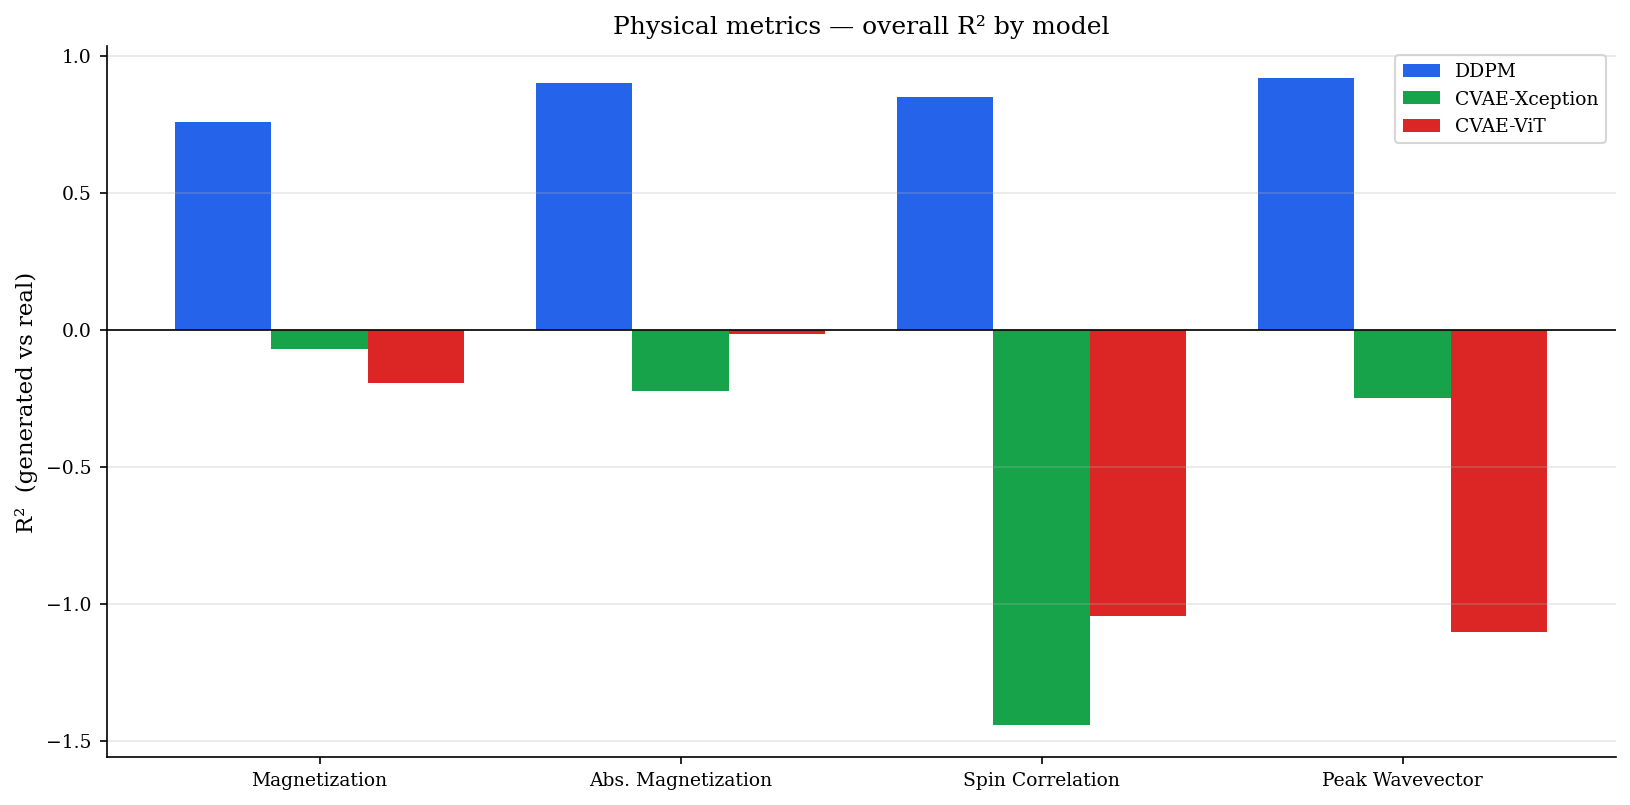

In [12]:
# ============================================================
# FIGURA 1 (general) — R² por métrica × modelo (12 barras)
# ============================================================
n_mdl = len(present)
x = np.arange(len(METRICS))
w = 0.8 / n_mdl
fig, ax = plt.subplots(figsize=(11, 5.5))
for i, mdl in enumerate(present):
    vals = [r2_general[mdl][m] for m in METRICS]
    ax.bar(x + (i - (n_mdl-1)/2)*w, vals, w, label=mdl, color=MODEL_COLORS.get(mdl, None))
ax.axhline(0, color="k", lw=0.8)
ax.set_xticks(x); ax.set_xticklabels([METRIC_LABEL[m] for m in METRICS])
ax.set_ylabel("R²  (generated vs real)")
ax.set_title("Physical metrics — overall R² by model")
ax.legend(); ax.grid(alpha=.3, axis="y")
plt.tight_layout()
plt.savefig(os.path.join(CACHE_DIR, "fig1_overall_r2.png"), dpi=150)
plt.show()

/tmp/ipykernel_2714/2160667753.py:17: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


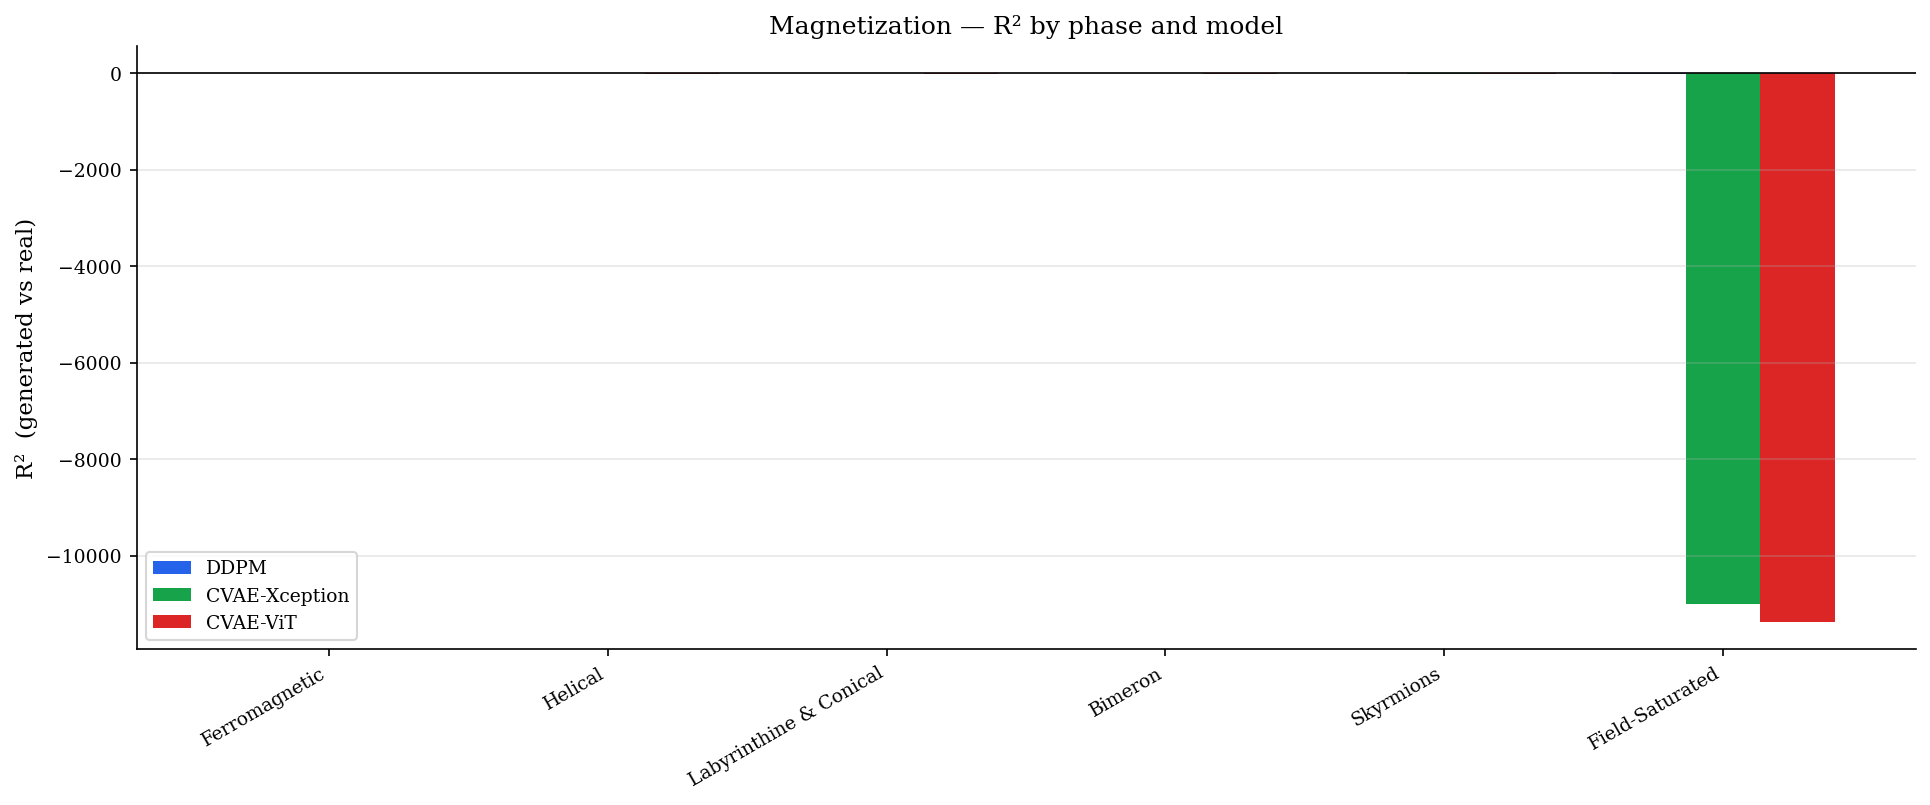

/tmp/ipykernel_2714/2160667753.py:17: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


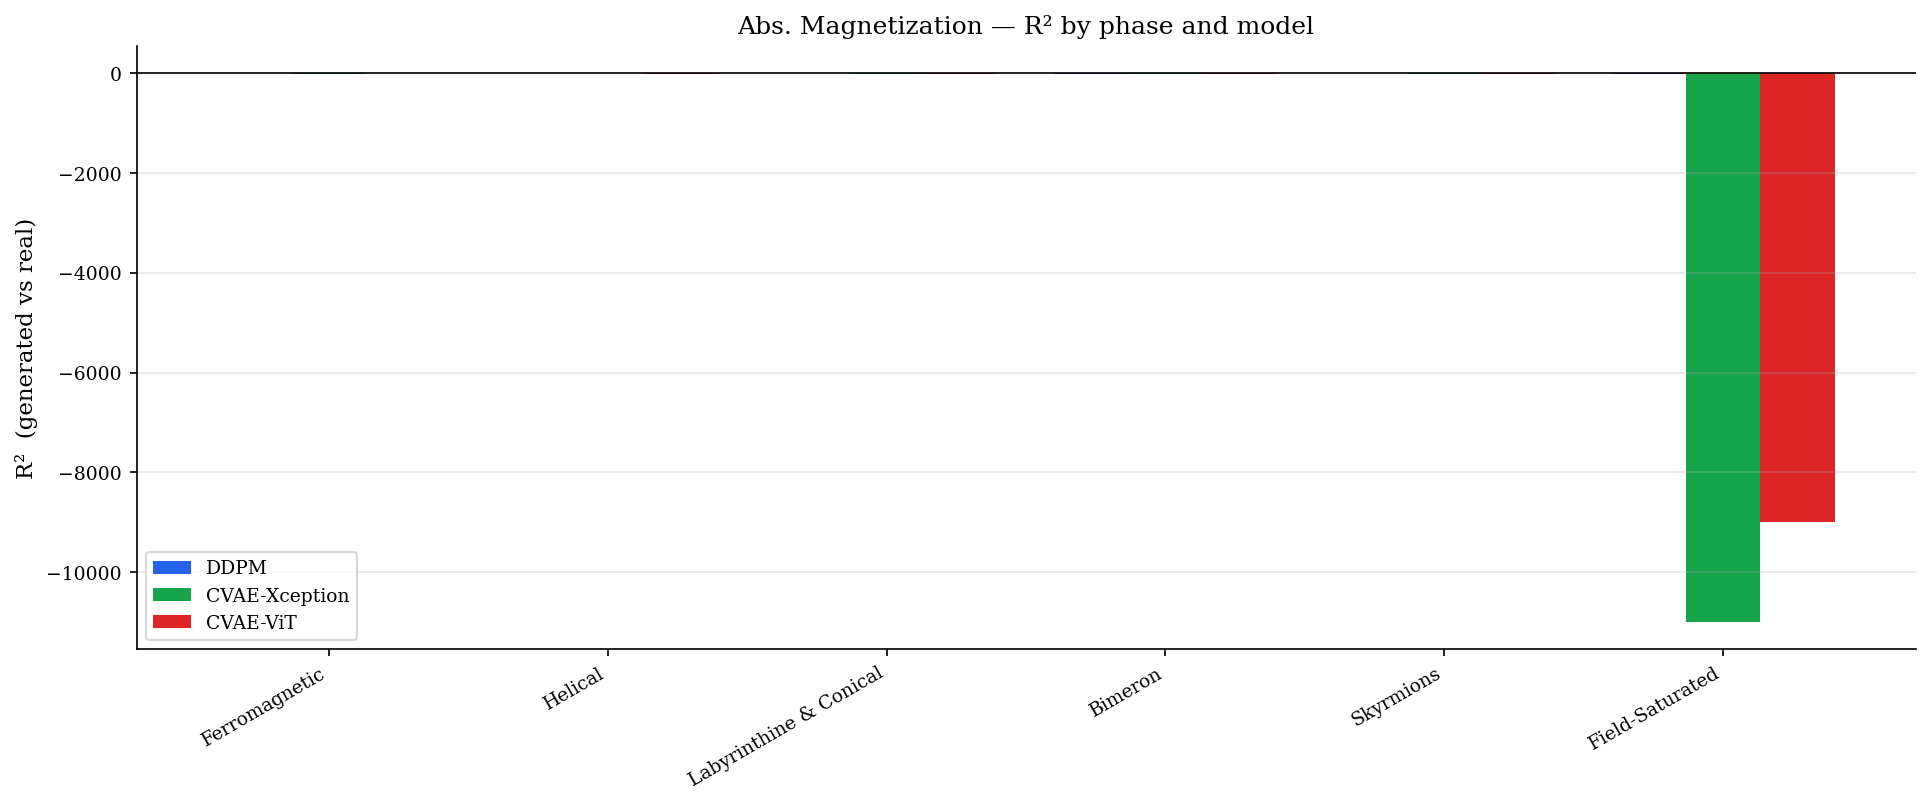

/tmp/ipykernel_2714/2160667753.py:17: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


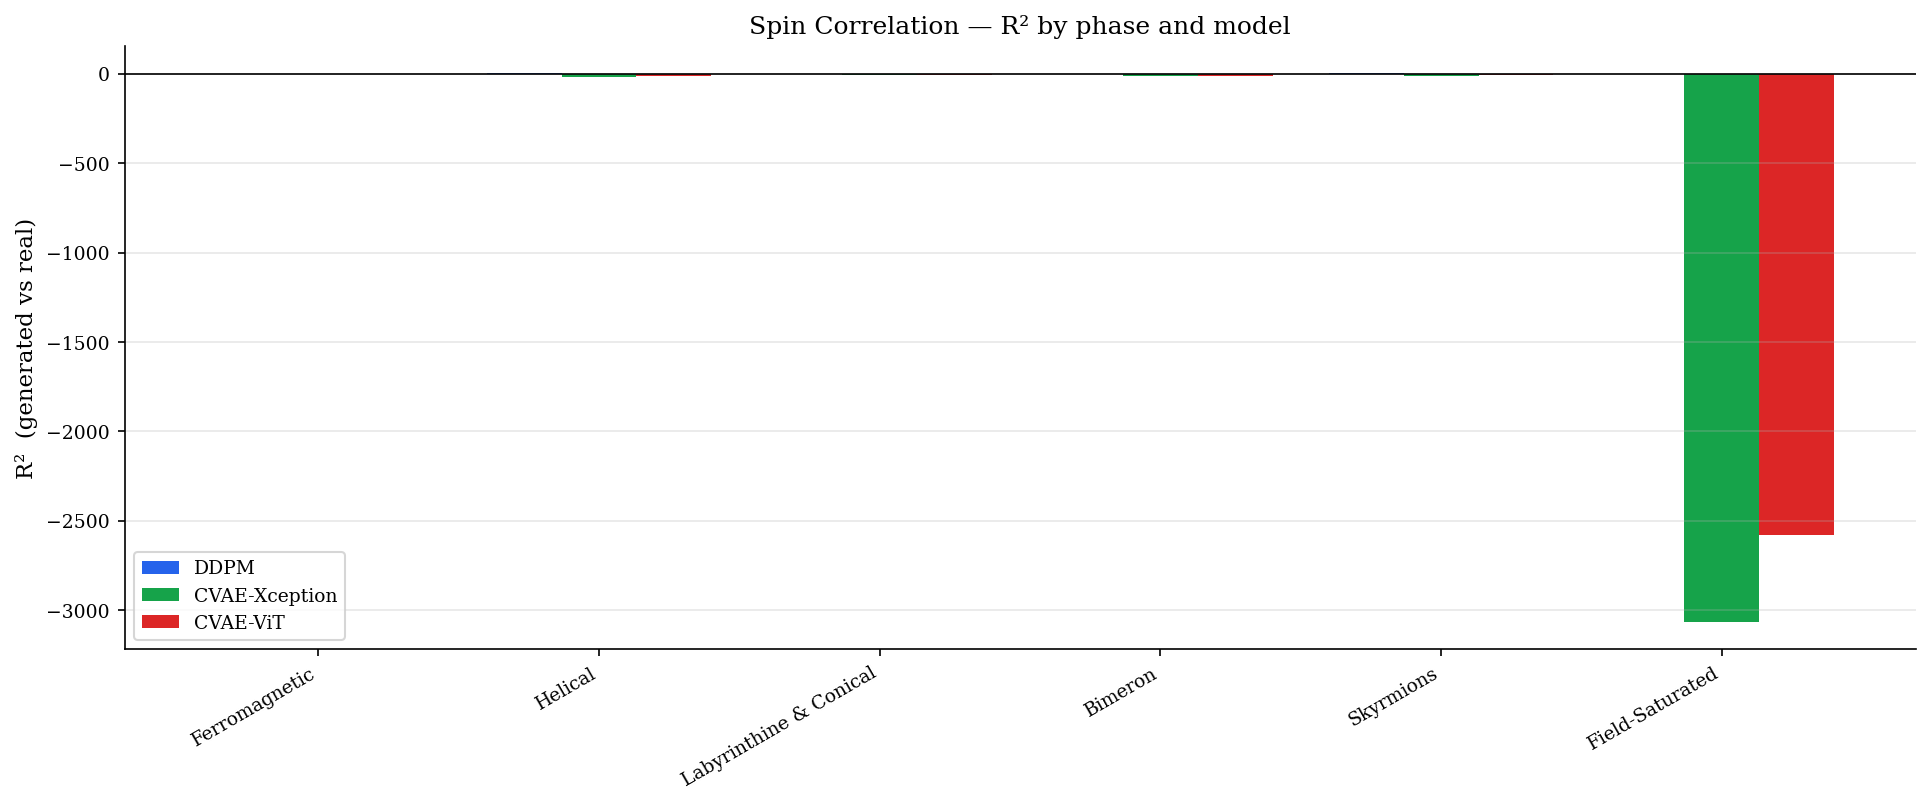

/tmp/ipykernel_2714/2160667753.py:17: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


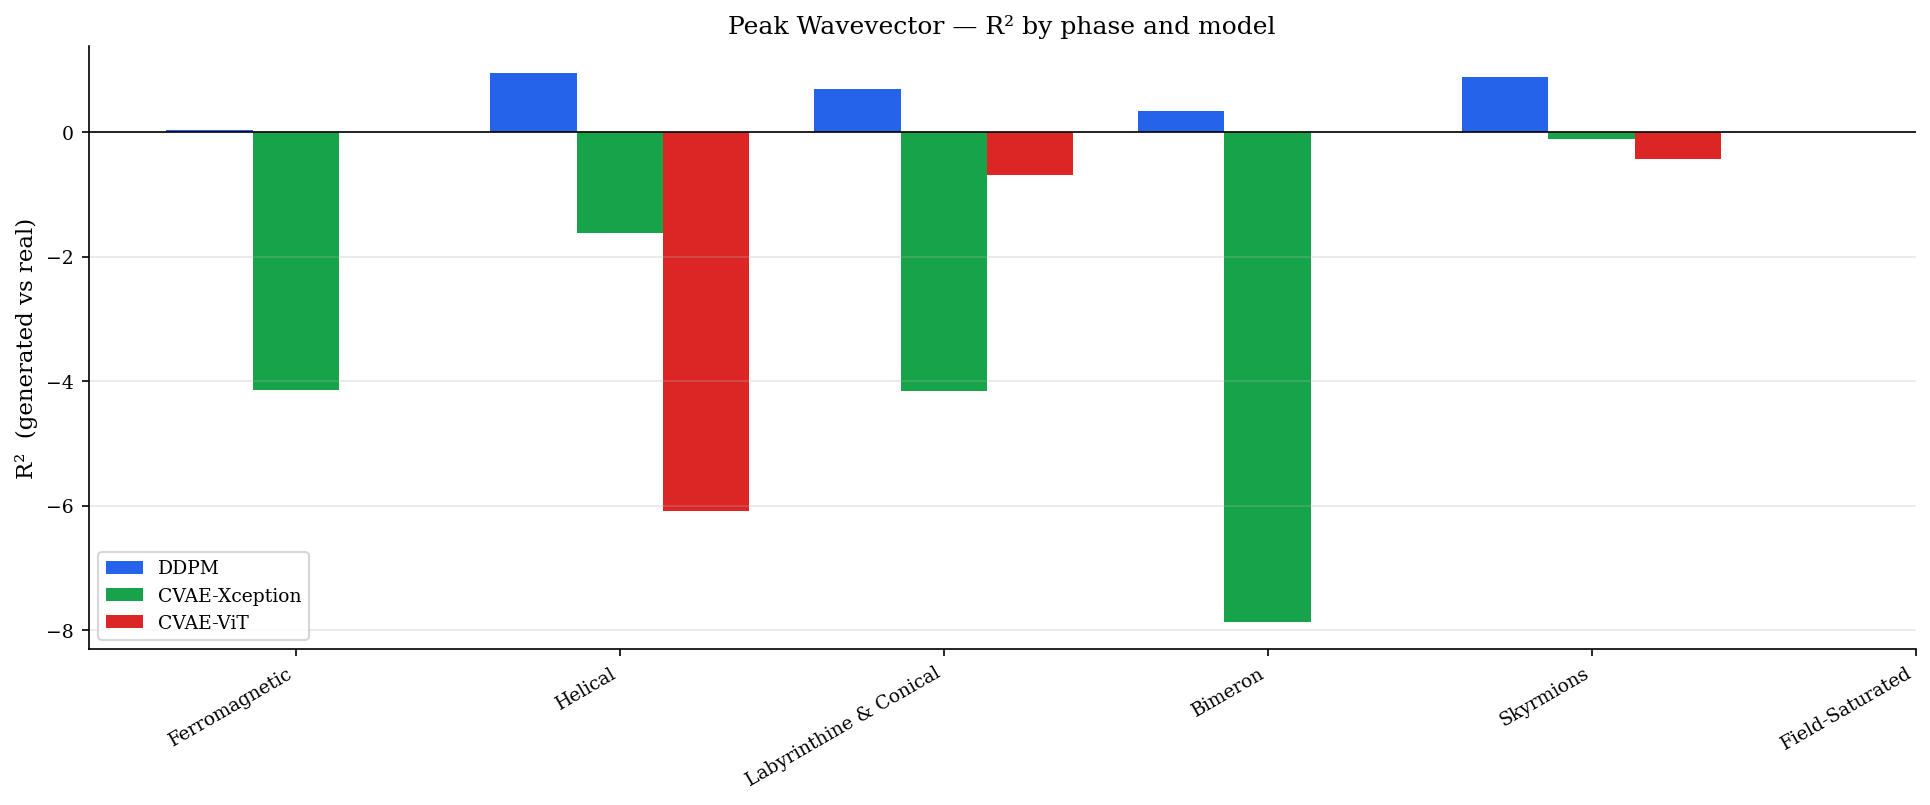

In [13]:
# ============================================================
# FIGURAS 2–5 (por métrica) — R² por fase × modelo (18 barras)
# ============================================================
xph = np.arange(len(STRUCTURE_NAMES))
w = 0.8 / n_mdl
for m in METRICS:
    fig, ax = plt.subplots(figsize=(13, 5.5))
    for i, mdl in enumerate(present):
        vals = [r2_phase[mdl][m][ph] for ph in STRUCTURE_NAMES]
        ax.bar(xph + (i - (n_mdl-1)/2)*w, vals, w, label=mdl, color=MODEL_COLORS.get(mdl, None))
    ax.axhline(0, color="k", lw=0.8)
    ax.set_xticks(xph)
    ax.set_xticklabels(STRUCTURE_NAMES, rotation=30, ha="right")
    ax.set_ylabel("R²  (generated vs real)")
    ax.set_title(f"{METRIC_LABEL[m]} — R² by phase and model")
    ax.legend(); ax.grid(alpha=.3, axis="y")
    plt.tight_layout()
    plt.savefig(os.path.join(CACHE_DIR, f"fig_{m}_r2_by_phase.png"), dpi=150)
    plt.show()

In [14]:
# ============================================================
# Guardar R² a CSV (general + por fase) para el paper
# ============================================================
import pandas as pd
rows = []
for mdl in present:
    for m in METRICS:
        rows.append({"model": mdl, "metric": METRIC_LABEL[m], "phase": "ALL", "r2": r2_general[mdl][m]})
        for ph in STRUCTURE_NAMES:
            rows.append({"model": mdl, "metric": METRIC_LABEL[m], "phase": ph, "r2": r2_phase[mdl][m][ph]})
df = pd.DataFrame(rows)
csv_path = os.path.join(CACHE_DIR, "physical_metrics_r2.csv")
df.to_csv(csv_path, index=False)
print(f"Guardado: {csv_path}  ({len(df)} filas)")
df.head(20)

Guardado: /content/eval_cache/physical_metrics_r2.csv  (84 filas)


,model,metric,phase,r2
0,DDPM,Magnetization,ALL,0.759132
1,DDPM,Magnetization,Ferromagnetic,-0.013893
2,DDPM,Magnetization,Helical,0.636903
3,DDPM,Magnetization,Labyrinthine & Conical,0.268479
4,DDPM,Magnetization,Bimeron,-0.186270
5,DDPM,Magnetization,Skyrmions,0.935677
6,DDPM,Magnetization,Field-Saturated,-17.442570
7,DDPM,Abs. Magnetization,ALL,0.901519
8,DDPM,Abs. Magnetization,Ferromagnetic,0.416610
9,DDPM,Abs. Magnetization,Helical,0.779290


In [20]:
# ============================================================
# PANEL · CELDA 1 de 3 — DDPM en GPU → genera 6 imgs y guarda a disco
# Autocontenida. Córrela en sesión con GPU (PyTorch). No depende de las etapas.
# ============================================================
import os, math
import numpy as np
import torch, torch.nn as nn, torch.nn.functional as F

DEV = "cuda" if torch.cuda.is_available() else "cpu"
IMG_SIZE, CROP_TO = 40, 39

# --- 1 θ por estructura (mismo criterio que el resto del notebook) ---
panel_phases = [p for p in STRUCTURE_NAMES if (eval_phase == p).any()]
_pr = np.random.RandomState(GEN_SEED)
_pi = np.array([int(_pr.choice(np.where(eval_phase == p)[0])) for p in panel_phases])
panel_cond = eval_cond[_pi].astype(np.float32)          # (P,8)
np.save(os.path.join(CACHE_DIR, "panel_Original.npy"), eval_imgs[_pi, :, :, 0])
np.save(os.path.join(CACHE_DIR, "panel_phases.npy"), np.array(panel_phases))

# --- arquitectura DDPM (idéntica al entrenamiento) ---
class _Sched:
    def __init__(self, T=1000, device="cpu"):
        steps=T+1; s=0.008; x=torch.linspace(0,T,steps,device=device)
        ac=torch.cos(((x/T)+s)/(1+s)*math.pi*0.5)**2; ac=ac/ac[0]
        b=(1-(ac[1:]/ac[:-1])).clamp(max=0.999); a=1.0-b; ac2=torch.cumprod(a,0)
        self.T=T; self.sa=ac2.sqrt(); self.s1=(1.0-ac2).sqrt()
def _sin(t,d):
    h=d//2; fr=torch.exp(-math.log(10000)*torch.arange(h,device=t.device).float()/(h-1))
    a=t[:,None].float()*fr[None]; return torch.cat([a.sin(),a.cos()],-1)
class _TCE(nn.Module):
    def __init__(s,td,ci,o):
        super().__init__(); s.t_mlp=nn.Sequential(nn.Linear(td,o),nn.SiLU(),nn.Linear(o,o)); s.c_mlp=nn.Sequential(nn.Linear(ci,o),nn.SiLU(),nn.Linear(o,o))
    def forward(s,t,c): return s.t_mlp(_sin(t,s.t_mlp[0].in_features))+s.c_mlp(c)
class _RB(nn.Module):
    def __init__(s,i,o,e,g=8,dropout=0.0):
        super().__init__(); s.norm1=nn.GroupNorm(g,i); s.conv1=nn.Conv2d(i,o,3,padding=1)
        s.norm2=nn.GroupNorm(g,o); s.conv2=nn.Conv2d(o,o,3,padding=1); s.emb_proj=nn.Linear(e,o)
        s.dropout=nn.Dropout(dropout) if dropout>0 else nn.Identity(); s.skip=nn.Conv2d(i,o,1) if i!=o else nn.Identity()
    def forward(s,x,e):
        h=F.silu(s.norm1(x)); h=s.conv1(h); h=h+s.emb_proj(F.silu(e))[:,:,None,None]
        h=F.silu(s.norm2(h)); h=s.dropout(h); h=s.conv2(h); return h+s.skip(x)
class _SA(nn.Module):
    def __init__(s,ch,g=8):
        super().__init__(); s.norm=nn.GroupNorm(g,ch); s.qkv=nn.Conv2d(ch,ch*3,1); s.proj=nn.Conv2d(ch,ch,1)
    def forward(s,x):
        B,C,H,W=x.shape; h=s.norm(x); q,k,v=s.qkv(h).chunk(3,1)
        q=q.reshape(B,C,-1); k=k.reshape(B,C,-1); v=v.reshape(B,C,-1)
        at=torch.softmax(torch.bmm(q.transpose(1,2),k)/math.sqrt(C),-1)
        return x+s.proj(torch.bmm(v,at.transpose(1,2)).reshape(B,C,H,W))
class _UNet(nn.Module):
    def __init__(s,base=80,emb=128,dropout=0.0,mults=(1,2,4),cd=8):
        super().__init__(); chs=[base*m for m in mults]
        s.emb=_TCE(emb,cd,emb); s.conv_in=nn.Conv2d(1,chs[0],3,padding=1)
        s.down_blocks=nn.ModuleList(); s.down_samples=nn.ModuleList(); inc=chs[0]; s.skip_channels=[]
        for i,o in enumerate(chs):
            s.down_blocks.append(nn.ModuleList([_RB(inc,o,emb,dropout=dropout),_RB(o,o,emb,dropout=dropout)])); s.skip_channels.append(o)
            s.down_samples.append(nn.Conv2d(o,o,4,stride=2,padding=1) if i<len(chs)-1 else nn.Identity()); inc=o
        s.mid_block1=_RB(chs[-1],chs[-1],emb,dropout=dropout); s.mid_attn=_SA(chs[-1]); s.mid_block2=_RB(chs[-1],chs[-1],emb,dropout=dropout)
        s.up_blocks=nn.ModuleList(); s.up_samples=nn.ModuleList()
        for i,o in enumerate(reversed(chs)):
            sk=s.skip_channels[-(i+1)]
            s.up_blocks.append(nn.ModuleList([_RB(inc+sk,o,emb,dropout=dropout),_RB(o,o,emb,dropout=dropout)]))
            s.up_samples.append(nn.ConvTranspose2d(o,o,4,stride=2,padding=1) if i<len(chs)-1 else nn.Identity()); inc=o
        s.norm_out=nn.GroupNorm(8,chs[0]); s.conv_out=nn.Conv2d(chs[0],1,1)
    def forward(s,x,t,c):
        e=s.emb(t,c); h=s.conv_in(x); sk=[]
        for (r1,r2),d in zip(s.down_blocks,s.down_samples):
            h=r1(h,e); h=r2(h,e); sk.append(h); h=d(h)
        h=s.mid_block1(h,e); h=s.mid_attn(h); h=s.mid_block2(h,e)
        for (r1,r2),u,k in zip(s.up_blocks,s.up_samples,reversed(sk)):
            h=torch.cat([h,k],1); h=r1(h,e); h=r2(h,e); h=u(h)
        return s.conv_out(F.silu(s.norm_out(h)))

@torch.no_grad()
def _sample(model,cond,sch,n_steps,sz=40):
    B=cond.shape[0]; x=torch.randn(B,1,sz,sz,device=cond.device)
    for tv in list(range(0,sch.T,sch.T//n_steps))[::-1]:
        tt=torch.full((B,),tv,device=cond.device,dtype=torch.long); eps=model(x,tt,cond)
        x0=((x-sch.s1[tv]*eps)/sch.sa[tv]).clamp(-1,1)
        if tv>0:
            tp=max(tv-sch.T//n_steps,0); x=sch.sa[tp]*x0+sch.s1[tp]*eps
        else: x=x0
    return x

ck=torch.load(DDPM_CKPT,map_location=DEV,weights_only=False)
hp=ck.get("hyperparams",{"base_ch":80,"cond_emb_dim":128,"dropout":0.1})
md=_UNet(base=hp["base_ch"],emb=hp["cond_emb_dim"],dropout=hp["dropout"]).to(DEV)
md.load_state_dict(ck["model"])
if ck.get("ema") is not None:
    with torch.no_grad():
        for n,p in md.named_parameters():
            if p.requires_grad and n in ck["ema"]: p.data.copy_(ck["ema"][n].to(DEV))
md.eval(); torch.manual_seed(GEN_SEED)
g=_sample(md, torch.from_numpy(panel_cond).to(DEV), _Sched(1000,DEV), FAST_STEPS, IMG_SIZE)
np.save(os.path.join(CACHE_DIR, "panel_DDPM.npy"), g[:,0,:CROP_TO,:CROP_TO].cpu().numpy())
print("Panel DDPM guardado:", os.path.join(CACHE_DIR, "panel_DDPM.npy"))

Panel DDPM guardado: /content/eval_cache/panel_DDPM.npy


In [6]:
import os, sys
os.environ.pop("TF_USE_LEGACY_KERAS", None)

# Si TF ya está importado, NO podemos cambiar el modo → hay que reiniciar.
if "tensorflow" in sys.modules:
    raise RuntimeError(
        "TF ya estaba importado en esta sesión. Reinicia el runtime y ejecuta "
        "ESTA celda ANTES de cualquier otra que importe TF (metrics.py, split, etc. "
        "no importan TF; pero NO ejecutes la 1ª celda de config legacy)."
    )

import numpy as np
import tensorflow as tf
import keras
print("Keras version:", keras.__version__)   # debe ser 3.x
assert keras.__version__.startswith("3"), f"Keras {keras.__version__} (legacy). Reinicia sin TF_USE_LEGACY_KERAS."


Keras version: 3.13.2


In [7]:
# ============================================================
# PANEL · CELDA 2A de 3 — CVAE-Xception (Keras 3) → 6 imgs, guarda a disco
# El cvae_xception.h5 tiene formato Keras-3 nuevo (claves layers/prior/vars) pero
# extensión .h5, así que Keras lo trata como legacy. Se copia a *.weights.h5 para
# forzar el deserializador nuevo.
#
# ⚠️ ORDEN: Restart runtime → corre rutas/metrics + split → ESTA celda.
#    NO ejecutes la 1ª celda de config (la que pone TF_USE_LEGACY_KERAS=1).
# ============================================================
import os, sys, shutil
os.environ.pop("TF_USE_LEGACY_KERAS", None)
os.environ["TF_USE_LEGACY_KERAS"] = "0"

import numpy as np
import tensorflow as tf
import keras
print("Keras:", keras.__version__, "| TF:", tf.__version__)

from tensorflow.keras import layers, regularizers, Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Input, Dropout, BatchNormalization
from tensorflow.keras.applications import Xception
from tensorflow import keras as K
for gpu in tf.config.list_physical_devices("GPU"):
    try: tf.config.experimental.set_memory_growth(gpu, True)
    except Exception: pass

panel_phases = list(np.load(os.path.join(CACHE_DIR, "panel_phases.npy")))
_pr = np.random.RandomState(GEN_SEED)
_pi = np.array([int(_pr.choice(np.where(eval_phase == p)[0])) for p in panel_phases])
panel_cond = eval_cond[_pi].astype(np.float32)

Z_DIM, COND_EMB_DIM, COND_DIM = 192, 32, 8

_inp = Input(shape=(224,224,3), name="input_layer")
_xc = Xception(weights=None, include_top=False, input_tensor=_inp, pooling=None)
_x = GlobalAveragePooling2D()(_xc.output); _x = BatchNormalization()(_x); _x = Dropout(0.4)(_x)
_x = Dense(256, activation="relu", kernel_regularizer=regularizers.l2(1e-4))(_x)
_x = BatchNormalization()(_x); _x = Dropout(0.3)(_x); _x = Dense(8, activation="linear")(_x)
_tmp = Model(_inp, _x, name="functional"); _tmp.load_weights(XPN_BACKBONE)
gap_layer = next(l for l in _tmp.layers if isinstance(l, GlobalAveragePooling2D))
backbone = Model(_tmp.input, gap_layer.input, name="xception_backbone"); del _tmp

class Sampling(layers.Layer):
    def call(self, inputs):
        mu, lv = inputs
        return mu + tf.random.normal(tf.shape(mu)) * tf.exp(0.5 * lv)
class Encoder(layers.Layer):
    def __init__(self, z_dim, cond_emb_dim, **kw):
        super().__init__(**kw)
        self.fc1 = Dense(512, activation="silu"); self.fc2 = Dense(256, activation="silu")
        self.fc_mu = Dense(z_dim); self.fc_lv = Dense(z_dim); self.sampling = Sampling()
    def call(self, emb, ce):
        h = self.fc2(self.fc1(tf.concat([emb, ce], axis=-1)))
        mu, lv = self.fc_mu(h), self.fc_lv(h)
        return mu, lv, self.sampling([mu, lv])
class Prior(layers.Layer):
    def __init__(self, z_dim, cond_emb_dim, **kw):
        super().__init__(**kw)
        self.cond_net = K.Sequential([Dense(64, activation="silu"), Dense(128, activation="silu"), Dense(cond_emb_dim, activation="silu")])
        self.fc_mu = Dense(z_dim); self.fc_lv = Dense(z_dim)
    def call(self, y):
        ce = self.cond_net(y); return self.fc_mu(ce), self.fc_lv(ce), ce
class Decoder(layers.Layer):
    def __init__(self, cond_emb_dim, **kw):
        super().__init__(**kw)
        self.fc_in = Dense(512 * 5 * 5, activation="silu"); self.reshape = layers.Reshape((5, 5, 512))
        self.up1 = layers.Conv2DTranspose(256, 4, strides=2, padding="same"); self.bn1 = layers.BatchNormalization()
        self.up2 = layers.Conv2DTranspose(128, 4, strides=2, padding="same"); self.bn2 = layers.BatchNormalization()
        self.up3 = layers.Conv2DTranspose(64, 4, strides=2, padding="same"); self.bn3 = layers.BatchNormalization()
        self.res1_c1 = layers.Conv2D(64, 3, padding="same"); self.res1_c2 = layers.Conv2D(64, 3, padding="same")
        self.res2_c1 = layers.Conv2D(64, 3, padding="same"); self.res2_c2 = layers.Conv2D(64, 3, padding="same")
        self.out_conv = layers.Conv2D(1, 1, activation="tanh")
    def call(self, z, ce, training=None):
        x = self.reshape(self.fc_in(tf.concat([z, ce], axis=-1)))
        x = tf.nn.silu(self.bn1(self.up1(x), training=training))
        x = tf.nn.silu(self.bn2(self.up2(x), training=training))
        x = tf.nn.silu(self.bn3(self.up3(x), training=training))
        h = tf.nn.silu(self.res1_c1(x)); x = tf.nn.silu(x + self.res1_c2(h))
        h = tf.nn.silu(self.res2_c1(x)); x = tf.nn.silu(x + self.res2_c2(h))
        return self.out_conv(x)
class CVAE_Xception(Model):
    def __init__(self, backbone, z_dim, cond_dim, cond_emb_dim, **kw):
        super().__init__(**kw)
        self.backbone = backbone; self.gap = GlobalAveragePooling2D()
        self.encoder = Encoder(z_dim, cond_emb_dim); self.prior = Prior(z_dim, cond_emb_dim); self.decoder = Decoder(cond_emb_dim)
    def call(self, inputs, training=None):
        img_xc, y = inputs
        emb = self.gap(self.backbone(img_xc, training=training))
        mu_p, lv_p, ce = self.prior(y); mu_q, lv_q, z = self.encoder(emb, ce)
        return self.decoder(z, ce, training=training), mu_q, lv_q, mu_p, lv_p
    def generate(self, y):
        mu_p, lv_p, ce = self.prior(y); return self.decoder(mu_p, ce, training=False)

model = CVAE_Xception(backbone, Z_DIM, COND_DIM, COND_EMB_DIM)
_ = model([tf.zeros((1,224,224,3)), tf.zeros((1,COND_DIM))], training=False)

# Forzar el parser NUEVO de Keras 3 copiando a extensión *.weights.h5
_w = CVAE_XPN_CKPT.replace(".h5", ".weights.h5")
if not os.path.exists(_w):
    shutil.copy(CVAE_XPN_CKPT, _w)
model.load_weights(_w)
print(f"CVAE-Xception cargado: {model.count_params():,} params")

gx = model.generate(tf.convert_to_tensor(panel_cond)).numpy()[:, :39, :39, 0]
np.save(os.path.join(CACHE_DIR, "panel_CVAE-Xception.npy"), gx)
print("Panel CVAE-Xception guardado:", gx.shape)

Keras: 3.13.2 | TF: 2.20.0
CVAE-Xception cargado: 27,965,193 params
Panel CVAE-Xception guardado: (6, 39, 39)


In [6]:
# ============================================================
# PANEL · CELDA 2B de 3 — CVAE-ViT → 6 imgs, guarda a disco
# El ViT necesita Keras 2 (TF_USE_LEGACY_KERAS=1) por TFViTModel.
#
# ⚠️ CÓMO CORRER (sesión SEPARADA de la 2A):
#    1) REINICIA el runtime.
#    2) 1ª celda CON TF_USE_LEGACY_KERAS=1 (o pon la env var antes de importar TF).
#    3) Ejecuta: rutas/metrics, split (para eval_*), luego esta celda.
#    El panel del Xception ya quedó en disco desde la celda 2A.
# ============================================================
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"        # Keras 2 (requerido por TFViTModel)
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                "transformers==4.44.2", "tf-keras"], check=False)
import numpy as np
import tensorflow as tf
tf.config.set_visible_devices([], "GPU")       # CPU
from tensorflow.keras import layers
from transformers import TFViTModel

panel_phases = list(np.load(os.path.join(CACHE_DIR, "panel_phases.npy")))
_pr = np.random.RandomState(GEN_SEED)
_pi = np.array([int(_pr.choice(np.where(eval_phase == p)[0])) for p in panel_phases])
panel_cond = eval_cond[_pi].astype(np.float32)

Zv, CEv, FEAT, NF = 128, 64, 768, 8
class _VB(tf.keras.layers.Layer):
    def __init__(s,**k):
        super().__init__(**k); s.vit=TFViTModel.from_pretrained("google/vit-base-patch16-224-in21k")
        s.vit.vit.embeddings.trainable=False
        for i,b in enumerate(s.vit.vit.encoder.layer): b.trainable=i>=NF
    def call(s,x,training=False):
        x=tf.image.resize(x,(224,224)); x=tf.image.grayscale_to_rgb(x); x=tf.transpose(x,[0,3,1,2])
        return tf.reduce_mean(s.vit(pixel_values=x,training=training).last_hidden_state,axis=1)
def _bp():
    c=layers.Input(shape=(8,)); e=layers.Dense(CEv,activation="relu",name="prior_cond_emb")(c)
    h=layers.Dense(64,activation="relu")(e); h=layers.Dense(128,activation="relu")(h)
    return tf.keras.Model(c,[layers.Dense(Zv,name="mu_p")(h),layers.Dense(Zv,name="log_var_p")(h)],name="prior_p")
def _bpost():
    f=layers.Input(shape=(FEAT,)); c=layers.Input(shape=(8,)); e=layers.Dense(CEv,activation="relu",name="post_cond_emb")(c)
    h=layers.Concatenate()([f,e]); h=layers.Dense(512,activation="relu")(h); h=layers.Dense(256,activation="relu")(h)
    return tf.keras.Model([f,c],[layers.Dense(Zv,name="mu_q")(h),layers.Dense(Zv,name="log_var_q")(h)],name="posterior_q")
def _rb(x,ch):
    h=layers.Conv2D(ch,3,padding="same",activation="relu")(x); h=layers.Conv2D(ch,3,padding="same")(h); return layers.Activation("relu")(layers.Add()([x,h]))
def _bd():
    z=layers.Input(shape=(Zv,)); c=layers.Input(shape=(8,)); e=layers.Dense(CEv,activation="relu",name="dec_cond_emb")(c)
    h=layers.Concatenate()([z,e]); h=layers.Dense(5*5*256,activation="relu")(h); h=layers.Reshape((5,5,256))(h)
    h=layers.Conv2DTranspose(128,4,strides=2,padding="same",activation="relu")(h)
    h=layers.Conv2DTranspose(64,4,strides=2,padding="same",activation="relu")(h)
    h=layers.Conv2DTranspose(32,4,strides=2,padding="same",activation="relu")(h)
    h=_rb(h,32); h=_rb(h,32); out=layers.Conv2D(1,3,padding="same",activation="tanh")(h)
    return tf.keras.Model([z,c],out,name="decoder")
class _CVAEV(tf.keras.Model):
    def __init__(s,**k):
        super().__init__(**k); s.backbone=_VB(name="vit_backbone"); s.posterior=_bpost(); s.prior=_bp(); s.decoder=_bd()
        s.beta=tf.Variable(1e-6,trainable=False,dtype=tf.float32,name="beta")
    def call(s,inp,training=False):
        x,y=inp; f=s.backbone(x,training=training); mq,lq=s.posterior([f,y],training=training)
        z=mq+tf.exp(0.5*lq)*tf.random.normal(tf.shape(mq)); return s.decoder([z,y],training=training)
    def sample_from_prior(s,y):
        y=tf.convert_to_tensor(y,tf.float32); mp,lp=s.prior(y,training=False)
        z=mp+tf.exp(0.5*lp)*tf.random.normal(tf.shape(mp)); return s.decoder([z,y],training=False).numpy().reshape(-1,40,40)
mv=_CVAEV(name="cvae_vit")
_=mv((eval_imgs[:2],eval_cond[:2])); _=mv.prior(tf.convert_to_tensor(eval_cond[:2],tf.float32))
mv.load_weights(CVAE_VIT_CKPT)
gv=mv.sample_from_prior(panel_cond)[:, :39, :39]
np.save(os.path.join(CACHE_DIR, "panel_CVAE-ViT.npy"), gv)
print("Panel CVAE-ViT guardado:", gv.shape)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/502 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

All PyTorch model weights were used when initializing TFViTModel.

All the weights of TFViTModel were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFViTModel for predictions without further training.


Panel CVAE-ViT guardado: (6, 39, 39)


/tmp/ipykernel_15096/1930726105.py:32: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


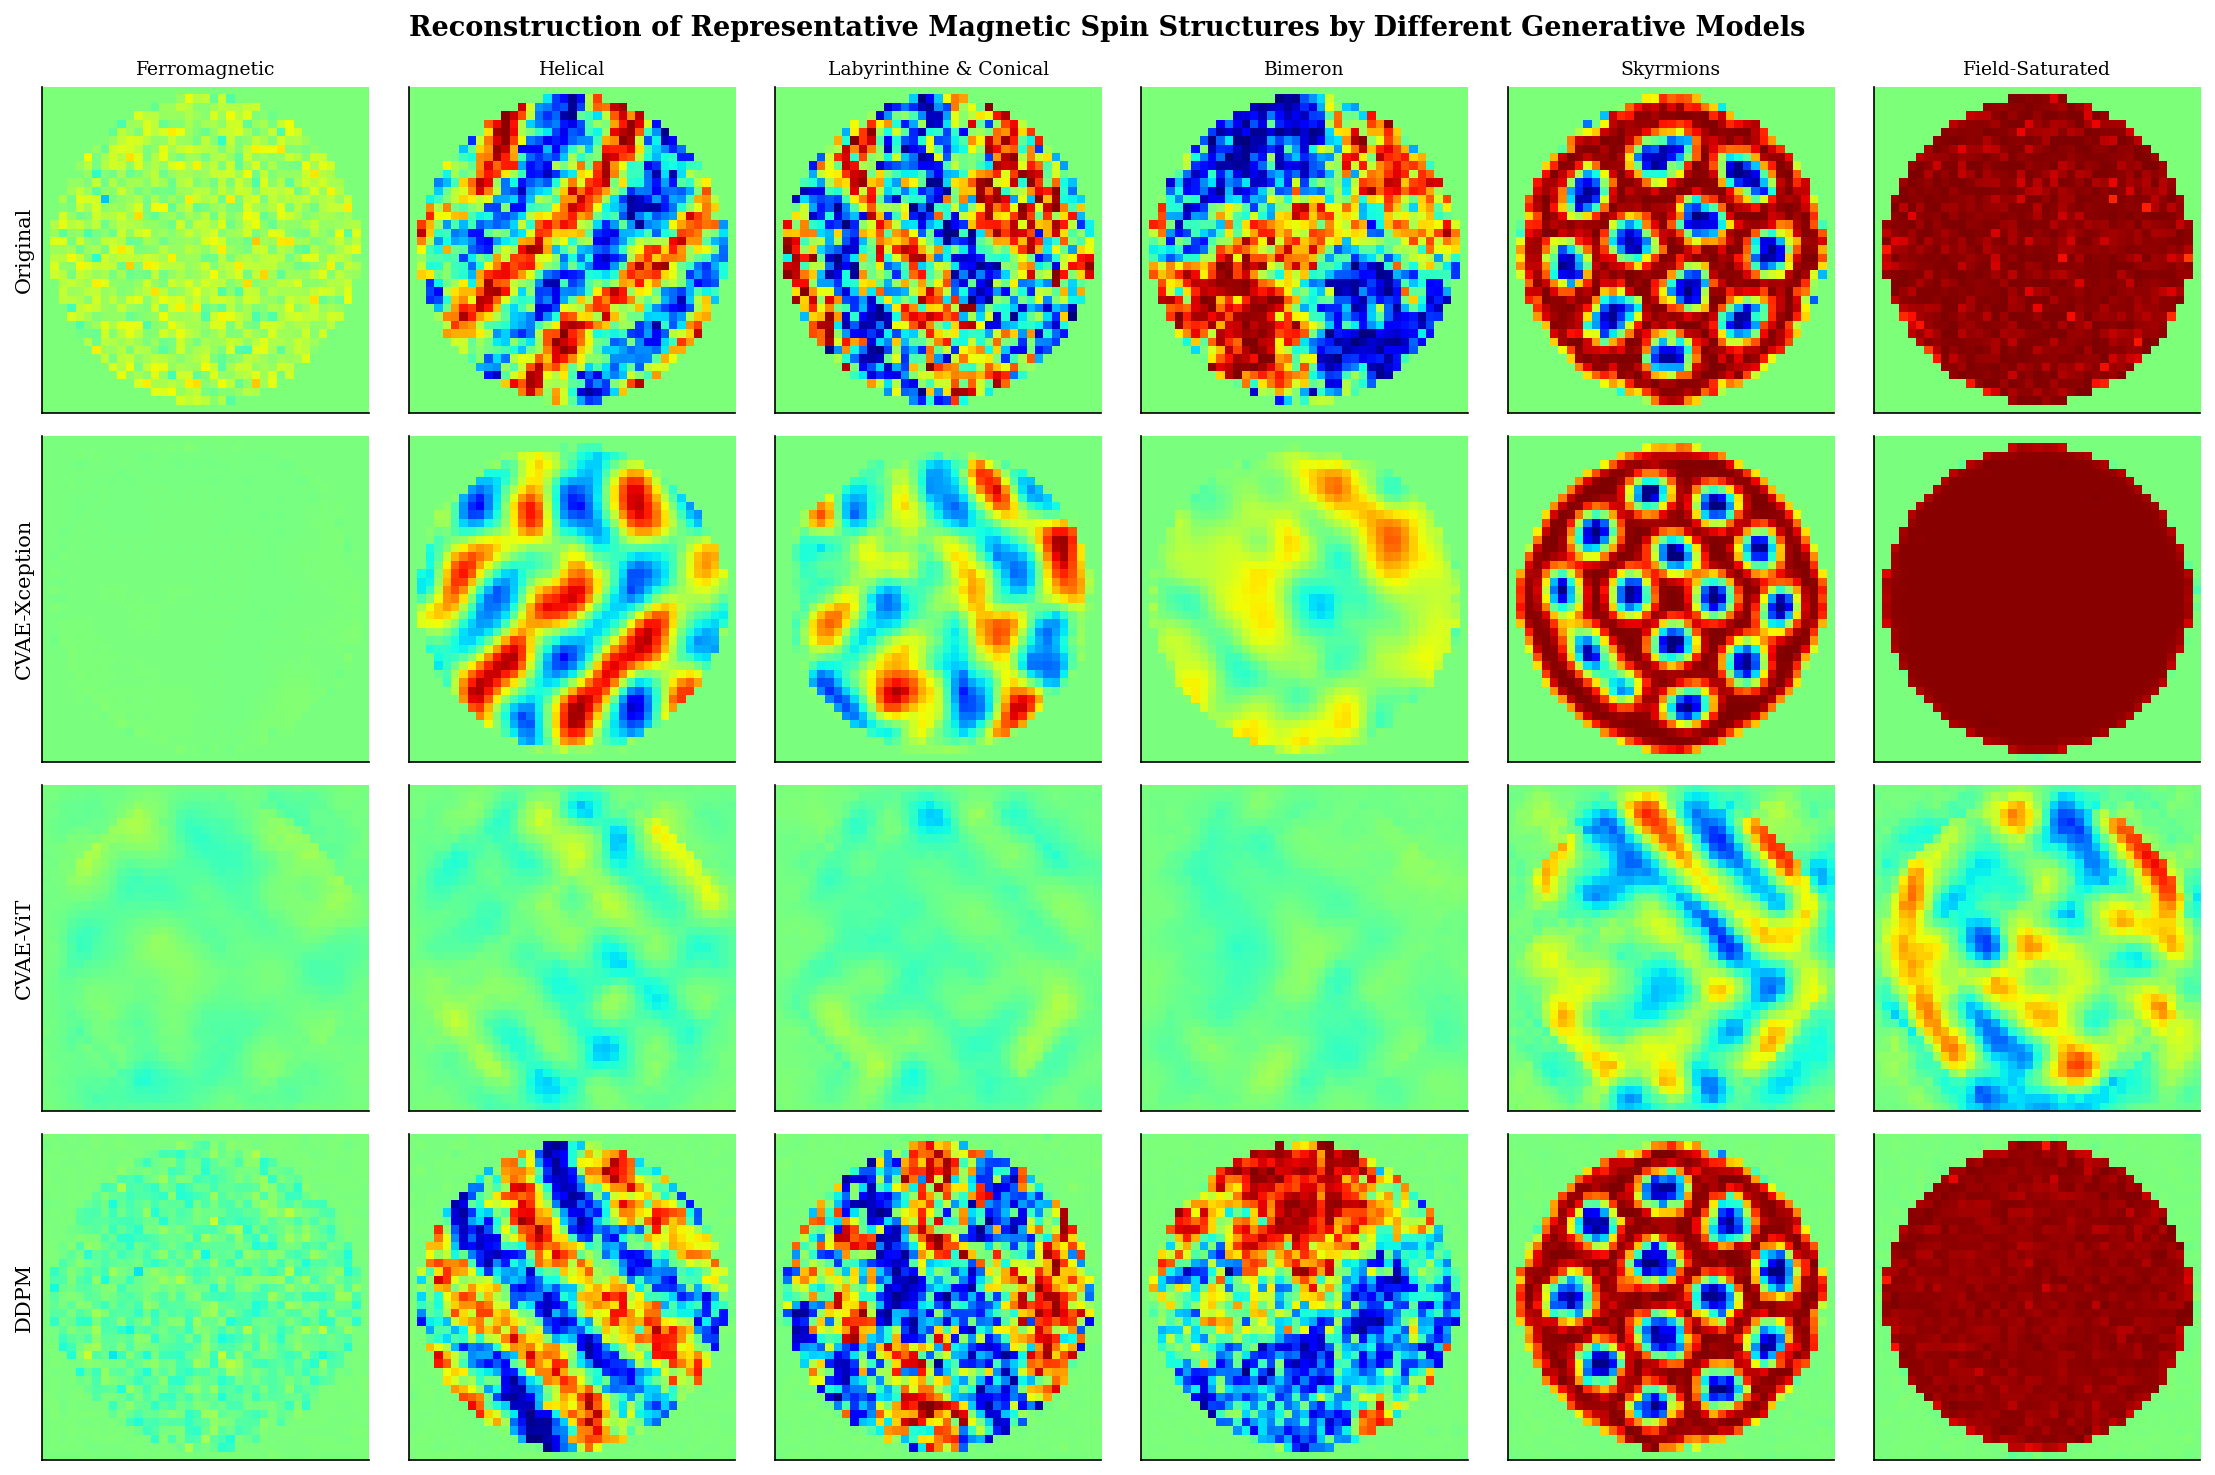

In [8]:
# ============================================================
# PANEL · CELDA 3 de 3 — lee los .npy guardados y dibuja la cuadrícula 4×6
# Solo lee de disco. Funciona en cualquier sesión (no carga modelos).
# ============================================================
import os
import numpy as np
import matplotlib.pyplot as plt

panel_phases = list(np.load(os.path.join(CACHE_DIR, "panel_phases.npy")))
row_order = ["Original", "CVAE-Xception", "CVAE-ViT", "DDPM"]

panels = {}
for name in row_order:
    p = os.path.join(CACHE_DIR, f"panel_{name}.npy")
    if os.path.exists(p):
        panels[name] = np.load(p)
    else:
        print(f"FALTA panel de {name} ({p}) — corre la celda 1 (DDPM) y/o 2 (CVAE).")

rows = [r for r in row_order if r in panels]
P = len(panel_phases)
fig, axes = plt.subplots(len(rows), P, figsize=(2.5*P, 2.5*len(rows)))
if len(rows) == 1: axes = axes[None, :]
for ri, rn in enumerate(rows):
    for ci, ph in enumerate(panel_phases):
        ax = axes[ri, ci]
        ax.imshow(panels[rn][ci], cmap="jet", vmin=-1, vmax=1, interpolation="nearest")
        ax.set_xticks([]); ax.set_yticks([])
        if ri == 0: ax.set_title(ph, fontsize=9)
        if ci == 0: ax.set_ylabel(rn, fontsize=10)
fig.suptitle("Reconstruction of Representative Magnetic Spin Structures by Different Generative Models", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(CACHE_DIR, "panel_struct_by_model.png"), dpi=150)
plt.show()